In [40]:
import pandas as pd 
import numpy as np
import seaborn as sns

In [42]:
df=pd.read_csv("emotion_sentiment_dataset.csv")

In [43]:
df.head(5)

,Unnamed: 0,text,Emotion
0,0,i seriously hate one subject to death but now ...,hate
1,1,im so full of life i feel appalled,neutral
2,2,i sit here to write i start to dig out my feel...,neutral
3,3,ive been really angry with r and i feel like a...,anger
4,4,i feel suspicious if there is no one outside l...,neutral


In [44]:


df = df.drop(columns=["Unnamed: 0"])

print(df.head())

                                                text  Emotion
0  i seriously hate one subject to death but now ...     hate
1                 im so full of life i feel appalled  neutral
2  i sit here to write i start to dig out my feel...  neutral
3  ive been really angry with r and i feel like a...    anger
4  i feel suspicious if there is no one outside l...  neutral


In [45]:
df['Emotion'].value_counts()

Emotion
neutral       674538
love           39553
happiness      27175
sadness        17481
relief         16729
hate           15267
anger          12336
fun            10075
enthusiasm      9304
surprise        6954
empty           5542
worry           4475
boredom          126
Name: count, dtype: int64

<Axes: xlabel='Emotion', ylabel='count'>

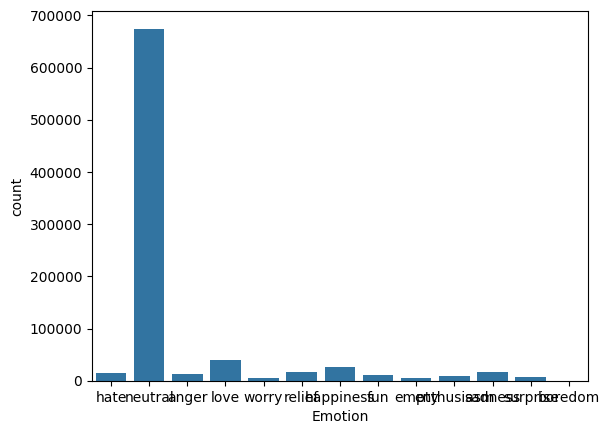

In [46]:
sns.countplot(x='Emotion',data=df)

In [47]:
df = df[df["Emotion"] != "boredom"]

In [48]:
balanced_data = (
    df.groupby("Emotion")
    .apply(lambda x: x.sample(n=min(len(x), 10000), random_state=42))
    .reset_index(drop=True)
)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29760\169916490.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 10000), random_state=42))


In [53]:
print(balanced_data["Emotion"].value_counts())

Emotion
anger         10000
fun           10000
hate          10000
happiness     10000
relief        10000
sadness       10000
love          10000
neutral       10000
enthusiasm     9304
surprise       6954
empty          5542
worry          4475
Name: count, dtype: int64


**BALANCED PLOT**

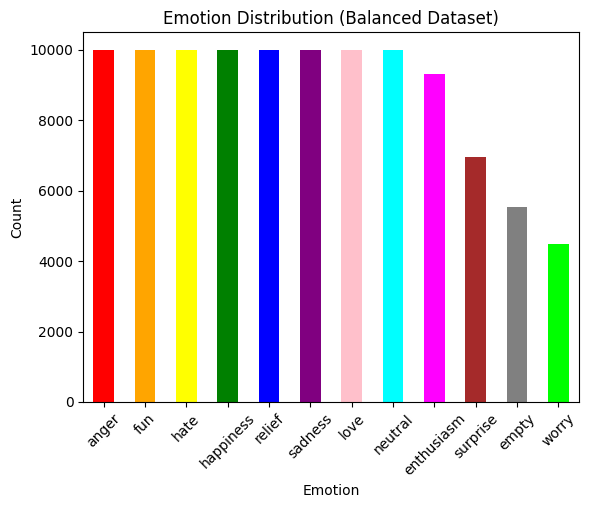

In [55]:
import matplotlib.pyplot as plt

counts = balanced_data["Emotion"].value_counts()

colors = [
    "red","orange","yellow","green","blue",
    "purple","pink","cyan","magenta",
    "brown","gray","lime"
]

counts.plot(kind="bar", color=colors)

plt.title("Emotion Distribution (Balanced Dataset)")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

**DATA PRE PROCESSING**

In [62]:
pip install neattext

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
pip install nfx


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
import neattext.functions as nfx
balanced_data['Clean_Text'] = balanced_data['text'].apply(nfx.remove_userhandles)

In [69]:
dir(nfx)

['BTC_ADDRESS_REGEX',
 'CURRENCY_REGEX',
 'CURRENCY_SYMB_REGEX',
 'Counter',
 'DATE_REGEX',
 'EMAIL_REGEX',
 'EMOJI_REGEX',
 'HASTAG_REGEX',
 'MASTERCard_REGEX',
 'MD5_SHA_REGEX',
 'MOST_COMMON_PUNCT_REGEX',
 'NUMBERS_REGEX',
 'PHONE_REGEX',
 'PoBOX_REGEX',
 'SPECIAL_CHARACTERS_REGEX',
 'STOPWORDS',
 'STOPWORDS_de',
 'STOPWORDS_en',
 'STOPWORDS_es',
 'STOPWORDS_fr',
 'STOPWORDS_ru',
 'STOPWORDS_yo',
 'STREET_ADDRESS_REGEX',
 'TextFrame',
 'URL_PATTERN',
 'USER_HANDLES_REGEX',
 'VISACard_REGEX',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__generate_text',
 '__loader__',
 '__name__',
 '__numbers_dict',
 '__package__',
 '__spec__',
 '_lex_richness_herdan',
 '_lex_richness_maas_ttr',
 'clean_text',
 'defaultdict',
 'digit2words',
 'extract_btc_address',
 'extract_currencies',
 'extract_currency_symbols',
 'extract_dates',
 'extract_emails',
 'extract_emojis',
 'extract_hashtags',
 'extract_html_tags',
 'extract_mastercard_addr',
 'extract_md5sha',
 'extract_numbers',
 'extr

**REMOVE THE STOP WORDS**

In [72]:
balanced_data['Clean_Text'] = balanced_data['Clean_Text'].apply(nfx.remove_stopwords)
balanced_data['Clean_Text'] = balanced_data['Clean_Text'].apply(nfx.remove_urls)
balanced_data['Clean_Text'] = balanced_data['Clean_Text'].apply(nfx.remove_special_characters)


In [73]:
balanced_data[['text','Clean_Text']].head()

,text,Clean_Text
0,i listen to when i feel discouraged as a write...,listen feel discouraged writer href http writi...
1,i feel a perverse thrill as i say this despite...,feel perverse thrill despite pain arms frighte...
2,i would continue to feel so irritated and even...,continue feel irritated angry
3,i feel afraid inside i realize that im angry i...,feel afraid inside realize im angry inside
4,i feel he broke up with his ex for her not tru...,feel broke ex trusting angry angry


**TF IDF**
**Now:**

**X → numerical features**

**y → emotion labels**

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(balanced_data['Clean_Text'])

y = balanced_data['Emotion']

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [83]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [85]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [86]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

In [87]:
from sklearn.metrics import accuracy_score

print("NB Accuracy:", accuracy_score(y_test, nb_pred))
print("LR Accuracy:", accuracy_score(y_test, lr_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

NB Accuracy: 0.8193366266760762
LR Accuracy: 0.9398729710656316
SVM Accuracy: 0.9526229122559398


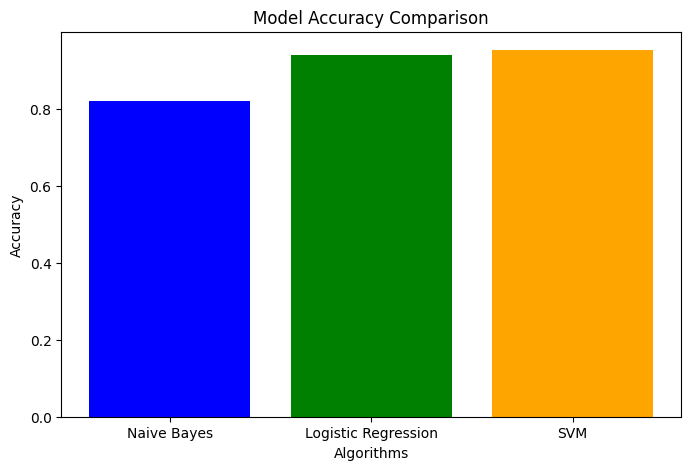

In [88]:
import matplotlib.pyplot as plt

models = ["Naive Bayes","Logistic Regression","SVM"]

scores = [0.819,0.939,0.952]

plt.figure(figsize=(8,5))

plt.bar(models, scores, color=["blue","green","orange"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xlabel("Algorithms")

plt.show()

In [89]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

       anger       0.98      0.99      0.99      2022
       empty       0.88      0.76      0.82      1127
  enthusiasm       1.00      1.00      1.00      1846
         fun       0.99      0.98      0.98      1984
   happiness       0.98      0.99      0.98      2058
        hate       0.96      0.87      0.92      2011
        love       0.98      0.98      0.98      1954
     neutral       0.76      0.91      0.83      2020
      relief       0.97      0.94      0.95      2024
     sadness       0.99      0.98      0.98      1933
    surprise       0.99      0.99      0.99      1408
       worry       1.00      0.99      1.00       868

    accuracy                           0.95     21255
   macro avg       0.96      0.95      0.95     21255
weighted avg       0.96      0.95      0.95     21255



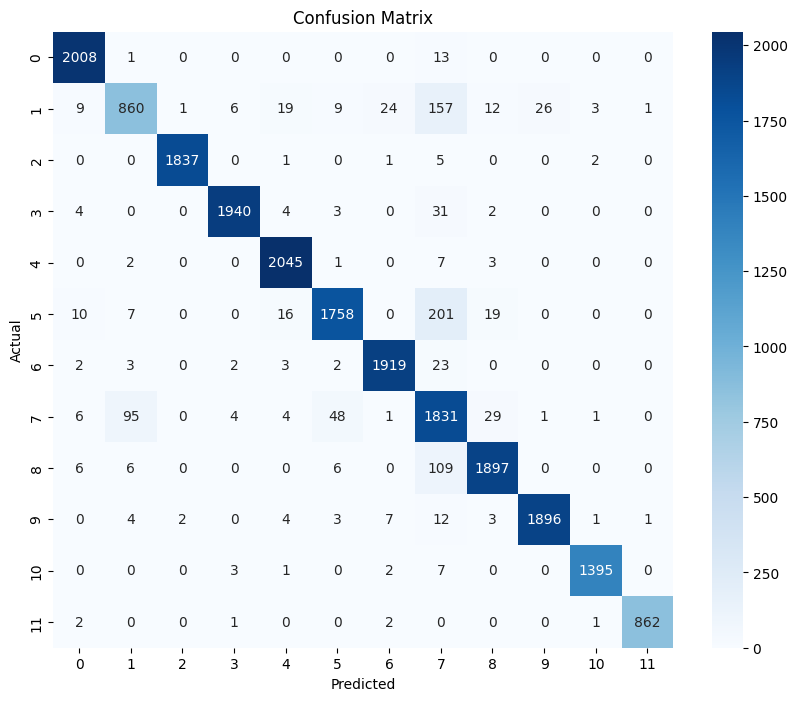

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [91]:
!pip install streamlit



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!streamlit run app.py

In [ ]:
sample = ["I feel very happy today"]

vec = tfidf.transform(sample)

svm_model.predict(vec)

In [ ]:
sample = ["I feel very happy today"]

vec = tfidf.transform(sample)

prediction = svm_model.predict(vec)[0]

print("Predicted Emotion:", prediction)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(balanced_data["Clean_Text"])

In [ ]:
print(svm_model)